## Exercise: Time Series Forecasting with Deep Learning

This notebook introduces time series forecasting using deep learning and recurrent neural networks (RNNs) with Keras. 

You will work with a real-world weather dataset and build models that predict future temperature values.

The notebook is divided into:

- A guided demonstration using a simple RNN

- Extensions where you experiment with LSTM and GRU models

- Exercises and theory questions

**Learning Objectives**

By the end of this exercise, you should be able to:

- Prepare time series data for supervised learning

- Build and train RNN-based forecasting models in Keras

- Perform single-step and multi-step forecasting

- Compare SimpleRNN, LSTM, and GRU architectures

- Reflect on model behavior and theoretical concepts


## 1. Dataset: Weather Time Series

We use the Jena Climate Dataset, a commonly used benchmark dataset for time series forecasting.

It contains 10-minute interval measurements such as:

- Temperature

- Humidity

- Air pressure

- Wind speed

For simplicity, we start by predicting temperature only.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
0       1307.75      1.03        

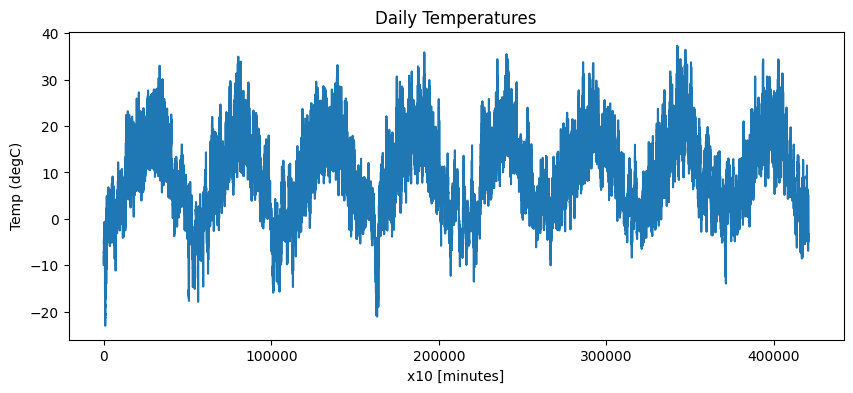

In [2]:

# Downloaded CSV from Jena Climate dataset
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
df = pd.read_csv(url)

print(df.head())

plt.figure(figsize=(10,4))
plt.plot(df['T (degC)'])
plt.title("Daily Temperatures")
plt.xlabel('x10 [minutes]')
plt.ylabel('Temp (degC)')
plt.show()


### Questions

- Which features are available in the dataset? \
From the information printed above we can read that we have the following features:\
The day and time \
The pressure, p, measured in millibar \
The tempearture in Celcius \
The potential Temperature in Kelvin, from what I can gather it is something like, the potiential from an adiabatic process at a fixed pressure \
The Dew Point Temeperature in Celcius \
The Relative Humidity in percent \
The saturation vapor pressure, which is the maximum pressure exerted by the water vapor at the given temperature in millibar\
The actual vapor pressure in millibar\
The vapor pressure deficit, the difference in the two above \
The specific humidity in [g/kg]\
The water vapor concentration in mmol/mol \
The air density in $g/m^3$ \
The wind velocity in $m/s$ \
The max or peak wind velocity in $m/s$ \
The wind direction in degrees\

- Which ones might be useful for forecasting temperature? \
While temperature is quite chaotic to predict, most of these features could prove usefull, the pressure was often used in barometers back in the day, the past Temperature would of course be helpfull to help predict the future Temperatures
Furthermore the humidity, to my knowledge, does not directly affect the temperature, it could however impact the rate of change since water takes more energy to heat than air does. The wind velocity and direction would also help to determine if hotter air is coming our way, it might be a problem that the direction is measured in degrees since 360 and 0 is the same but could confuse the model since they are numerically far apart.

## 2. Prepare Sequences


- Select the temperature column

- Normalize values

- Create supervised learning sequences

In [3]:
temperature = df['T (degC)'].values.reshape(-1, 1)

scaler = MinMaxScaler()
temperature_scaled = scaler.fit_transform(temperature)

def create_sequences(data, seq_len=24):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)


SEQ_LEN = 24 # last 24 time steps
X, y = create_sequences(temperature_scaled, SEQ_LEN)

split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]


## 3. Simple RNN Forecasting Model (Single-Step)

In [4]:

model = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(SEQ_LEN, 1)),
    Dense(1)
    ])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\bruger\.conda\envs\ml_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train and Evaluate

In [5]:

results = []

history = model.fit(
        X_train, y_train,
        epochs=10,
        validation_data=(X_val, y_val),
        batch_size=64
        )


Epoch 1/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.4011e-04 - val_loss: 3.7085e-05
Epoch 2/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.9124e-05 - val_loss: 3.1377e-05
Epoch 3/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.3436e-05 - val_loss: 1.2270e-05
Epoch 4/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.3016e-05 - val_loss: 1.2333e-05
Epoch 5/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2841e-05 - val_loss: 1.1732e-05
Epoch 6/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2712e-05 - val_loss: 1.2075e-05
Epoch 7/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2443e-05 - val_loss: 1.2021e-05
Epoch 8/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2447e-05 - val_loss: 1.6587e-05
Epoch 9/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2384e-05 - val_loss: 1.7022e-05
Epoch 10/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 1.2401e-05 - val_loss: 1.1834e-05


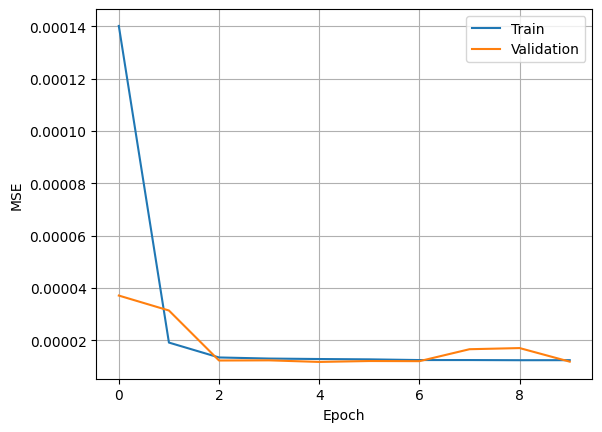

In [6]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

## 4. Evaluate model and validation dataset

In [7]:
preds = model.predict(X_val)

y_true = scaler.inverse_transform(y_val)
y_pred = scaler.inverse_transform(preds)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("RMSE", rmse, "MAE", mae)


2629/2629 ━━━━━━━━━━━━━━━━━━━━ 2s 713us/step
RMSE 0.20740049467557767 MAE 0.1320114072293584


## 5. Single-Step Forecasting

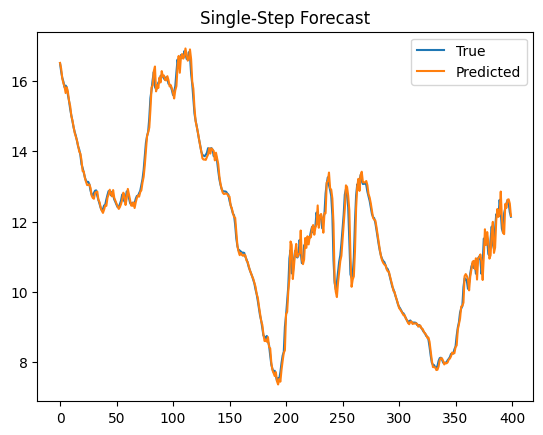

In [8]:

plt.plot(y_true[:400], label='True')
plt.plot(y_pred[:400], label='Predicted')
plt.legend()
plt.title('Single-Step Forecast')
plt.show()


## 6. Multi-Step Forecasting

We now predict multiple future time steps recursively by using the below function.

In [9]:
def multi_step_forecast(model, start_seq, steps=24):
    current_seq = start_seq.copy()
    preds = []
    for _ in range(steps):
        next_val = model.predict(current_seq[np.newaxis, ...])[0]
        preds.append(next_val)
        current_seq = np.roll(current_seq, -1, axis=0)
        current_seq[-1] = next_val
    return np.array(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[0.6555495 ]
 [0.65301275]
 [0.65046597]
 [0.64794135]
 [0.645419  ]
 [0.64288974]
 [0.6403569 ]
 [0.6378249 ]
 [0.63530946]
 [0.6328205 ]]


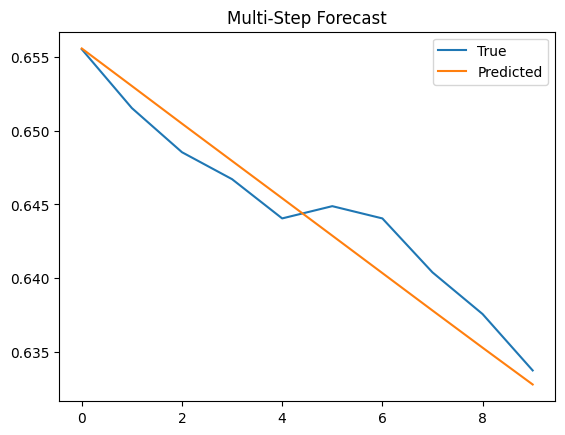

In [10]:
preds = multi_step_forecast(model, X_val[0], steps=10)
print(preds)

plt.plot(y_val[:10], label='True')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title('Multi-Step Forecast')
plt.show()

## 7. Extend model with LSTM and GRU (Task)

Replace the SimpleRNN layer with:

- LSTM

- GRU

Example:

- LSTM(32, input_shape=(SEQ_LEN, 1))

- GRU(32, input_shape=(SEQ_LEN, 1))

Compare:

- Convergence speed

- Validation loss

- Forecast stability

## LSTM

In [12]:
model = Sequential([
    LSTM(32, input_shape=(SEQ_LEN, 1)),
    Dense(1)
    ])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\bruger\.conda\envs\ml_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 4.4685e-04 - val_loss: 3.9382e-05
Epoch 2/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 3.1010e-05 - val_loss: 2.5941e-05
Epoch 3/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.7783e-05 - val_loss: 1.4978e-05
Epoch 4/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.3109e-05 - val_loss: 1.4739e-05
Epoch 5/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2704e-05 - val_loss: 1.1733e-05
Epoch 6/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 1.2500e-05 - val_loss: 1.3569e-05
Epoch 7/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2458e-05 - val_loss: 1.2102e-05
Epoch 8/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2334e-05 - val_loss: 1.1754e-05
Epoch 9/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2314e-05 - val_loss: 1.2927e-05
Epoch 10/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2327e-05 - val_loss: 1.4371e-05


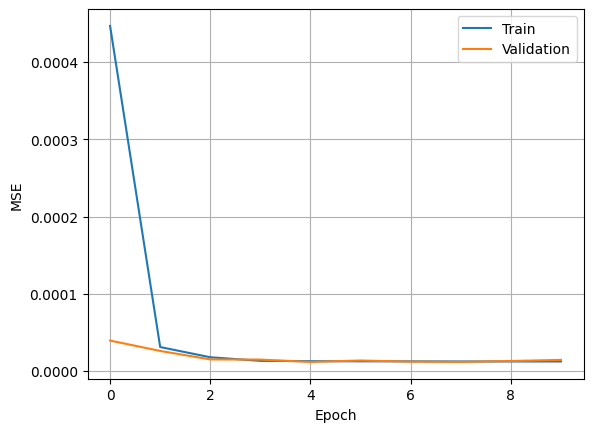

In [13]:
results = []

history = model.fit(
        X_train, y_train,
        epochs=10,
        validation_data=(X_val, y_val),
        batch_size=64
        )

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[0.6542927 ]
 [0.6498584 ]
 [0.64528346]
 [0.64057773]
 [0.63574314]
 [0.6307849 ]
 [0.6257097 ]
 [0.62052524]
 [0.6152409 ]
 [0.6098651 ]]


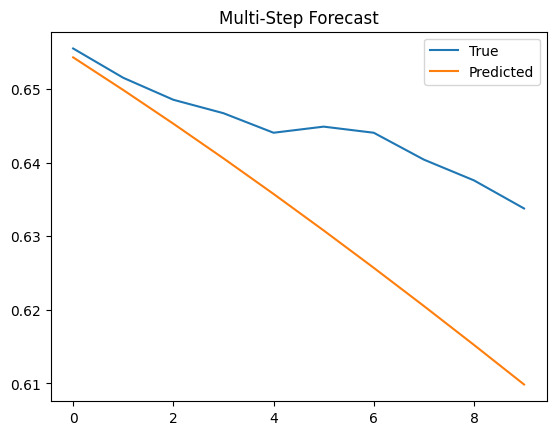

In [14]:
preds = multi_step_forecast(model, X_val[0], steps=10)
print(preds)

plt.plot(y_val[:10], label='True')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title('Multi-Step Forecast')
plt.show()

## GRU

In [15]:
model = Sequential([
    GRU(32, input_shape=(SEQ_LEN, 1)),
    Dense(1)
    ])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 2.6323e-04 - val_loss: 1.6889e-05
Epoch 2/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 1.7321e-05 - val_loss: 2.2602e-05
Epoch 3/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 1.4099e-05 - val_loss: 1.2920e-05
Epoch 4/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 1.3183e-05 - val_loss: 2.4792e-05
Epoch 5/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1.3016e-05 - val_loss: 1.2234e-05
Epoch 6/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 1.2808e-05 - val_loss: 1.3208e-05
Epoch 7/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 1.2657e-05 - val_loss: 1.5871e-05
Epoch 8/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1.2674e-05 - val_loss: 1.3863e-05
Epoch 9/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1.2595e-05 - val_loss: 1.3976e-05
Epoch 10/10
5257/5257 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - loss: 1.2458e-05 - val_loss: 1.3002e-05


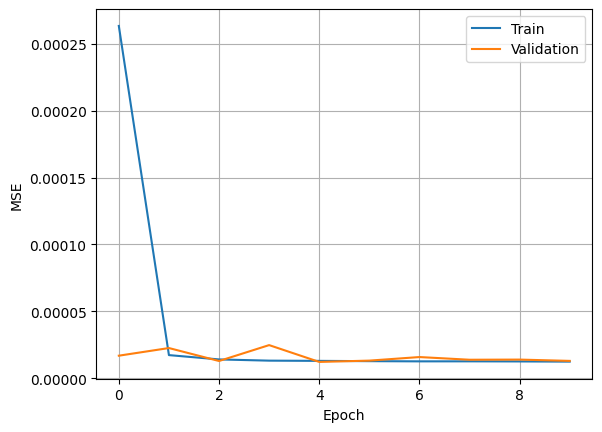

In [16]:
results = []

history = model.fit(
        X_train, y_train,
        epochs=10,
        validation_data=(X_val, y_val),
        batch_size=64
        )

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[[0.6575279 ]
 [0.657856  ]
 [0.6583419 ]
 [0.6589794 ]
 [0.6598293 ]
 [0.66090167]
 [0.6621916 ]
 [0.663693  ]
 [0.6654013 ]
 [0.66731435]]


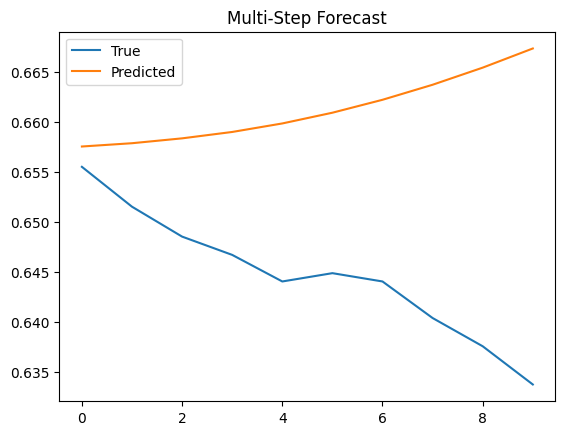

In [17]:
preds = multi_step_forecast(model, X_val[0], steps=10)
print(preds)

plt.plot(y_val[:10], label='True')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title('Multi-Step Forecast')
plt.show()

We see that for both of them the validation loss starts low and remains low in the order $10^-5$, on top of that they both seem to converge after one epoch, the thing that really sets them apart is their forecast stability, where the LSTM at least seems to get the idea and direction, albeit not as closely as the RNN model. The GRU model however, completely misses the mark and goes off in the wrong direction.

## 8. Questions and reflection

### Questions

- Q8.a) Why are RNNs suitable for time series forecasting? \
RNNs do better due to their "feedback loop" where they not only consider the input at say time t, but also the previous state e.g. t-1. It is part of the fundamentals of the RNN that maintains a hidden state, which functions as a form of memory. This makes it better at not only learning and predicting one value from the given features, but predict the direction of the coming values based on those that came before. (Source: wikipedia "Recurrent Neural Network") \
\
- Q8.b) What are the limitations of RNN-based forecasting? \
RNNs do however suffer from a vanishing gradient problem, where the gradients used to update the weights shrink exponentially when looking furhter back in time, which lead to what can be described as a long term memory lapse, where the short term memory gains bigger influence than the long term.\

- Q8.c) What problem does LSTM solve compared to SimpleRNN?\
The LSTM or Long Short-Term Memory network tries to solve this by adding gates that keeps track of the older gradients for longer expanding the memory of the model.\

- Q8.d) What causes error accumulation in multi-step forecasting?\
Oftentimes the problem is the fact that when predicting say 3 days ahead, the model will predict one day ahead and use that prediction as the input for the prediction for day two, that way the errors will compound and grow the further down the future we move.\
\
- Q8.e) How does sequence length affect forecasting performance?\
Too short of a sequence length will lead to too little knowledge to properly predict, if we say only had the weather for the night it would be hard to predict the warmth of the sun during the day. If the sequence length becomes too long we either hit the problem of the vanishing gradient with the RNN or we force the LSTM to carry so much data that the .fit will take far too much time, probably with data that does not make that big a difference. Like life it is about finding the balance.

- Q8.f) Which model performed best and why?
All three models hit about the same validation loss, but the prediction power of the RNN became clear when performing the multi step forecast. To be more specific the RNN also reached the best validation loss of the three, 



### Deliverables:

- Completed notebook with experiments
- Plots and answers to questions
- Short written reflection on results

REVISIONS||
:- | :-
2022-01-23| KBE, initial.                  